In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install mlflow pyngrok --quiet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyngrok.ngrok as ngrok
import subprocess
import getpass
import mlflow
import mlflow.sklearn

In [4]:
# 1. Set the experiment name and uri
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("employee_attrition")

<Experiment: artifact_location='/content/mlruns/1', creation_time=1786118505703, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1786118505703, lifecycle_stage='active', name='employee_attrition', tags={}, trace_location=None, workspace='default'>

In [83]:
!chmod -R 755 mlruns mlflow.db

In [5]:
NGROK_AUTH_TOKEN = "3HaqleXoPGtIuYwbossJy6Qc4hz_5JUZcdF6BSiGfyhLjbZco"
!ngrok config add-authtoken {NGROK_AUTH_TOKEN}

DB_URI = "sqlite:///mlflow.db"
mlflow.set_tracking_uri(DB_URI)

# FIX: Add --allowed-hosts "*" to explicitly accept the ngrok domain format
subprocess.Popen([
    "mlflow", "ui",
    "--backend-store-uri", DB_URI,
    "--port", "5000",
    "--host", "0.0.0.0",
    "--allowed-hosts", "*"
])

print("MLflow tracking server restarted with wildcard host permissions.")

# Securely prompt for your token to protect your account credentials
print("Enter your ngrok Auth Token:")
#NGROK_TOKEN = getpass.getpass()

# Authenticate and spin up the public tunnel
ngrok.set_auth_token(NGROK_AUTH_TOKEN)
ngrok_tunnel = ngrok.connect(addr="5000", proto="http")

print("---" * 15)
print(f"Click this link to open your MLflow UI: {ngrok_tunnel.public_url}")
print("---" * 15)

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
MLflow tracking server restarted with wildcard host permissions.
Enter your ngrok Auth Token:
---------------------------------------------
Click this link to open your MLflow UI: https://erratic-graceless-regalia.ngrok-free.dev
---------------------------------------------


In [6]:
df = pd.read_csv("/content/drive/MyDrive/data_employee_attrition.csv")

In [7]:
df.head() # target feature is Attrition it has values Yes or No so it is classification problem

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [8]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [9]:
df.shape    # rows=1470, columns=35

(1470, 35)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [11]:
num_colmns = df.select_dtypes(include=['number'])
cat_colmns = df.select_dtypes(include=['object'])

In [12]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


'''
By observing the mean and 50% the feature 'DistanceFromHome' is right skwed and 'EmployeeNumber' is also little right skwed.
The 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion' and 'YearsWithCurrManager' its 75% amd max values comparionsion is very high, it may containe outliers.

'''

In [13]:
df.describe(include="object")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


#The featute Over18 has only 1 unique value so it will not contribute any thing for prediction, we can drop this feature

In [14]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [15]:
df.isnull().sum()   #There is no missing values present in the dateset

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [16]:
duplicates = df.duplicated().sum()  #There are no duplicates present in the dataset
print(duplicates)

0


In [17]:
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


# 'StandardHours ,'Over18' and  'EmployeeCount' has only 1 unique vale it will not contribute for prediction so we can drop these 3 features

In [18]:
(df['Attrition'].value_counts(normalize=True)*100)/len(['Attrition'])

,proportion
Attrition,
No,83.877551
Yes,16.122449


# #Target feature has an imbalanced data

/tmp/ipykernel_112562/1599895865.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


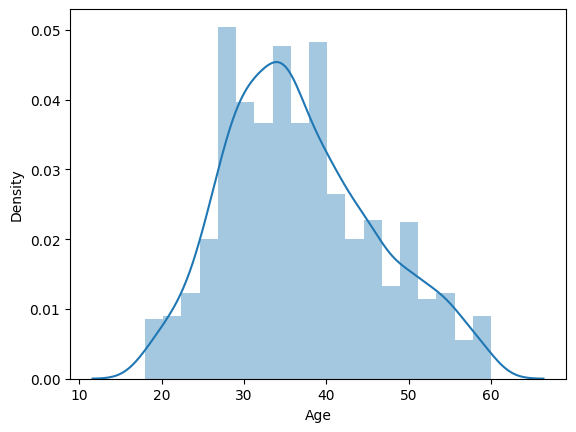

In [19]:
sns.distplot(df['Age'])
plt.show()

<Axes: xlabel='Department'>

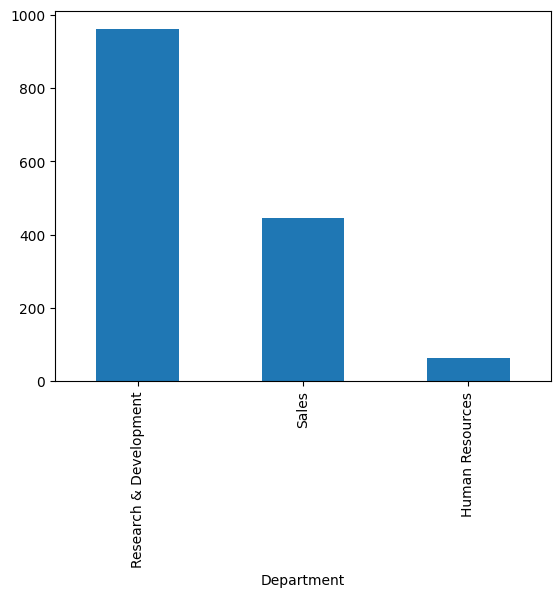

In [20]:
df["Department"].value_counts().plot(kind="bar")

In [21]:
df.corr(numeric_only=True)   # bivariate analysis Numerical vs Numerical

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,...,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


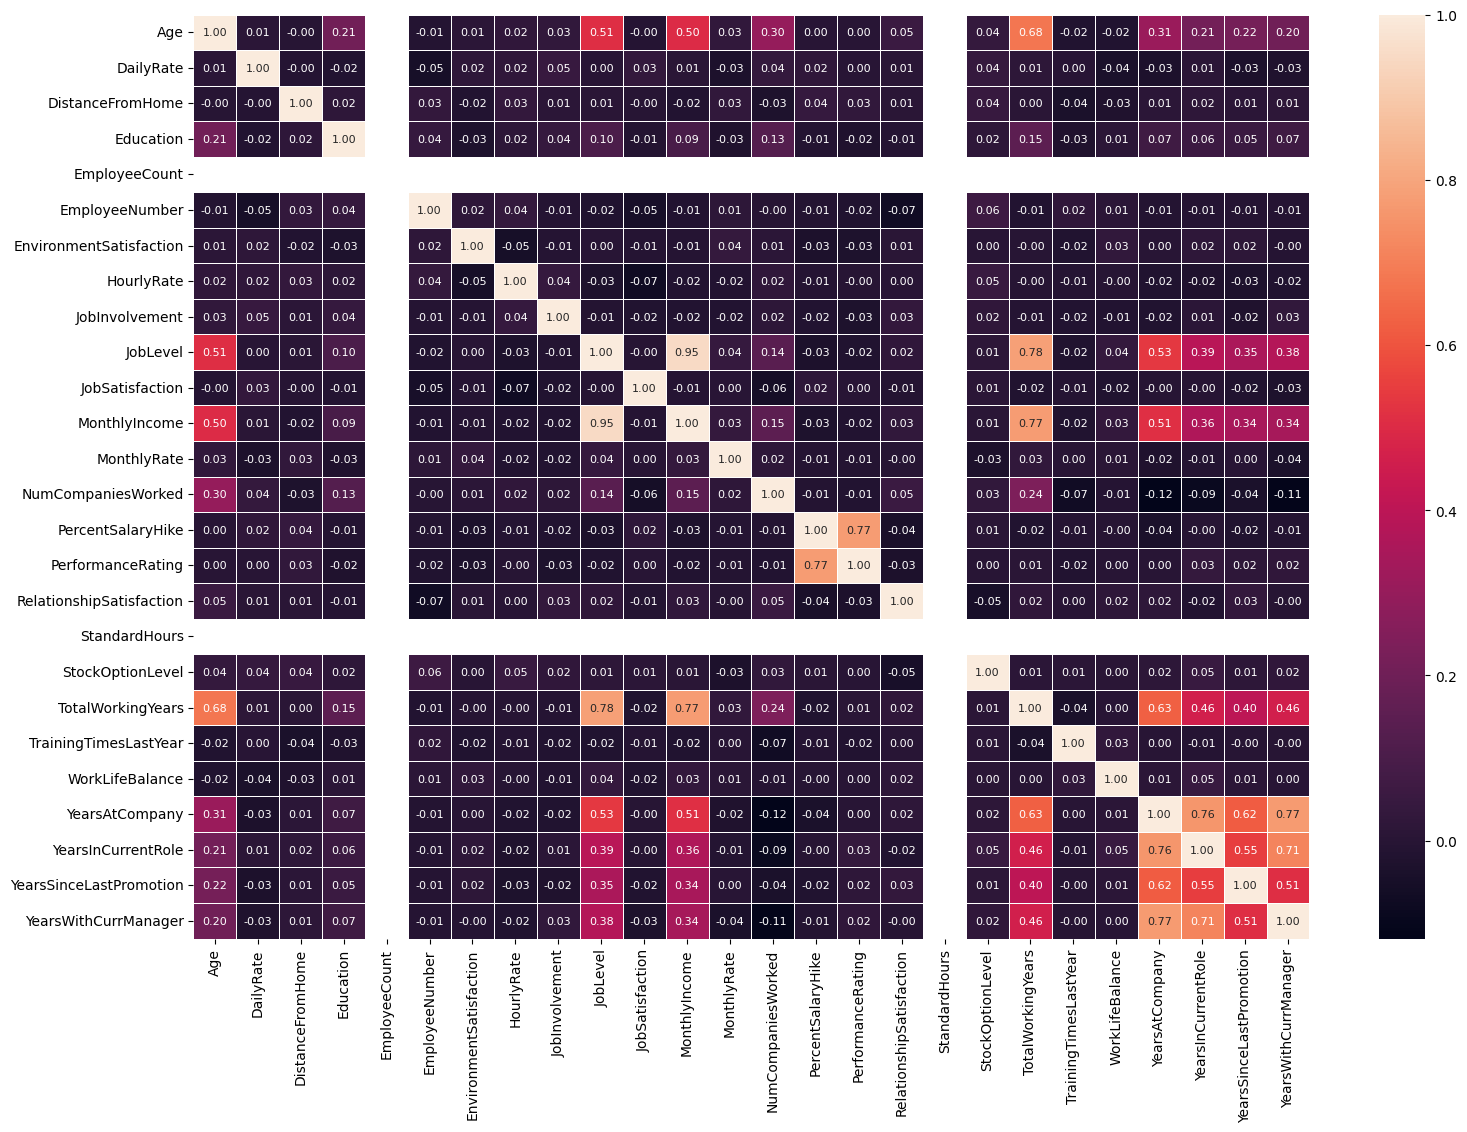

In [22]:
plt.figure(figsize=(18,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", linewidths=0.5, annot_kws={"size":8})
plt.show()

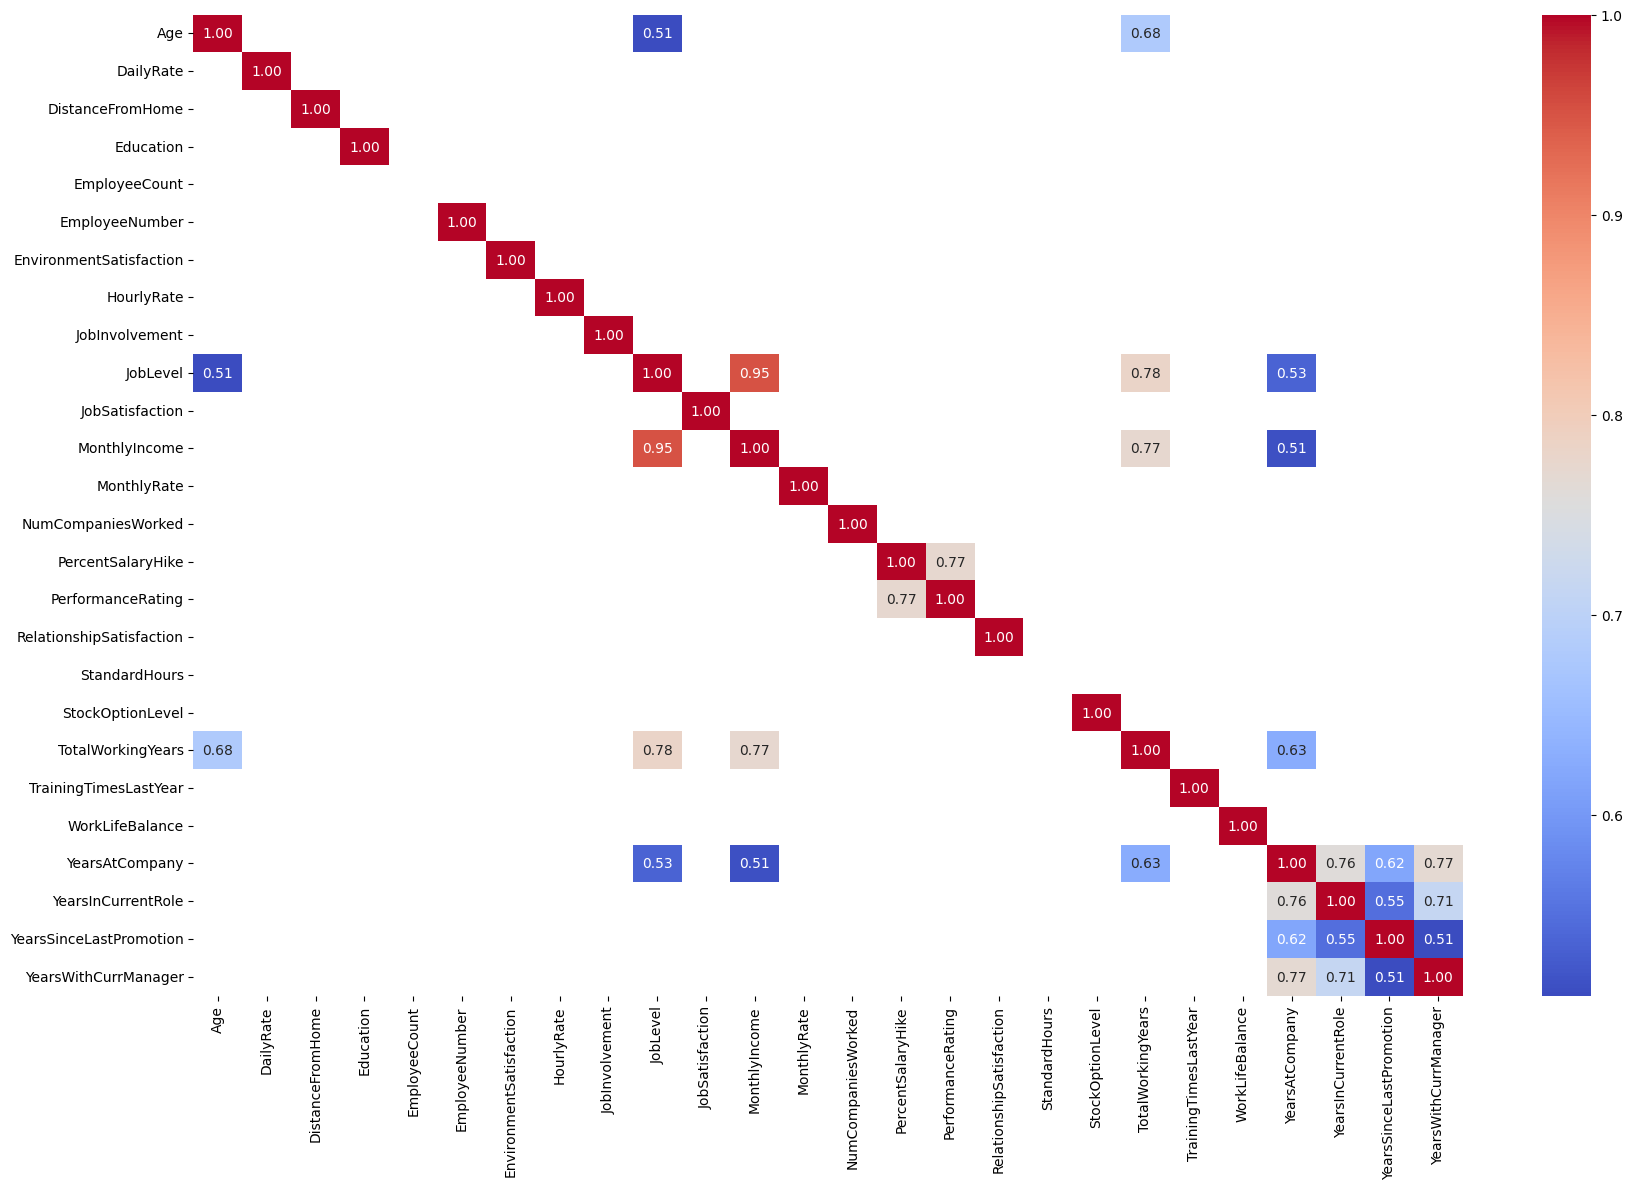

In [23]:
# highly correlated features
corr = df.corr(numeric_only=True)

plt.figure(figsize=(18, 12))
sns.heatmap(
    corr[(corr.abs() > 0.5)],
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.tight_layout()
plt.show()

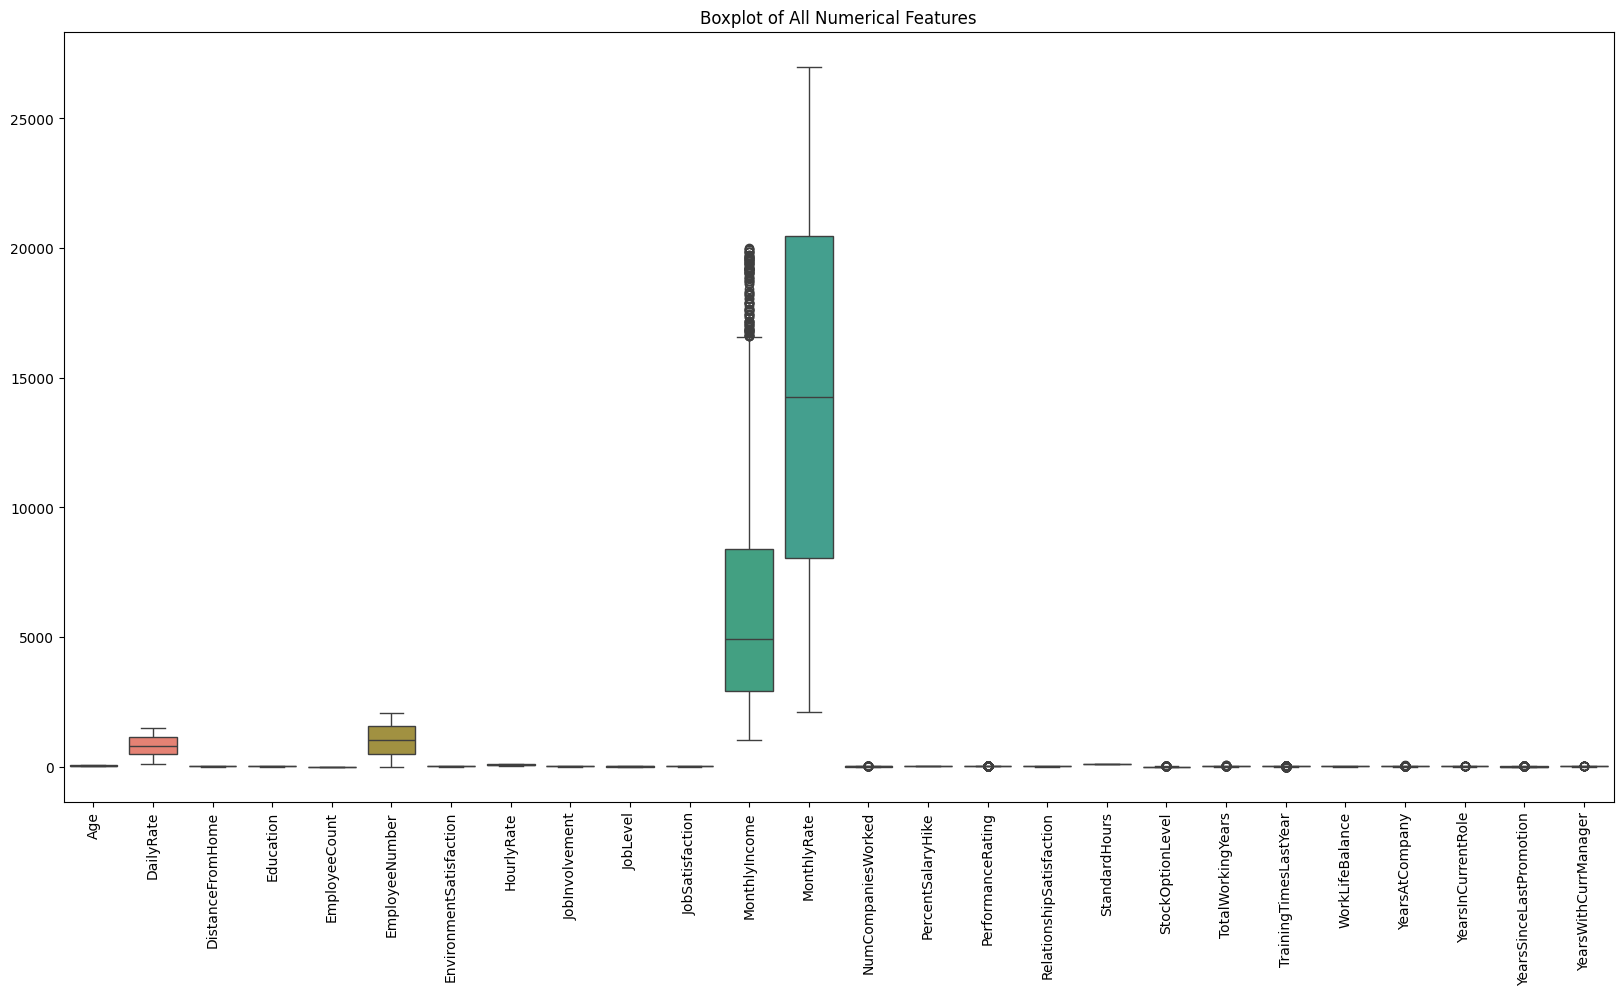

In [24]:
num_colmns = df.select_dtypes(include='number').columns
plt.figure(figsize=(20, 10))
sns.boxplot(data=df[num_colmns])

plt.xticks(rotation=90)
plt.title("Boxplot of All Numerical Features")
plt.show()

As per above boxplot observation MonthlyIncome feature has outliers

In [25]:
outlier_summary = []

for col in num_colmns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Outlier Count": count,
        "Outlier %": round((count / len(df)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values("Outlier Count", ascending=False)

,Column,Outlier Count,Outlier %
20,TrainingTimesLastYear,238,16.19
15,PerformanceRating,226,15.37
11,MonthlyIncome,114,7.76
24,YearsSinceLastPromotion,107,7.28
22,YearsAtCompany,104,7.07
18,StockOptionLevel,85,5.78
19,TotalWorkingYears,63,4.29
13,NumCompaniesWorked,52,3.54
23,YearsInCurrentRole,21,1.43
25,YearsWithCurrManager,14,0.95


In [26]:
df.skew(numeric_only=True) # To check skew in the data

,0
Age,0.413286
DailyRate,-0.003519
DistanceFromHome,0.958118
Education,-0.289681
EmployeeCount,0.000000
EmployeeNumber,0.016574
EnvironmentSatisfaction,-0.321654
HourlyRate,-0.032311
JobInvolvement,-0.498419
JobLevel,1.025401


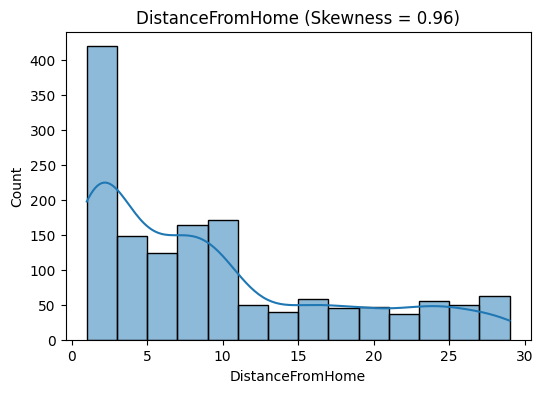

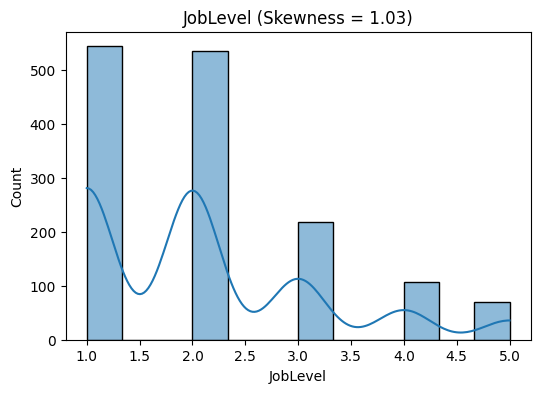

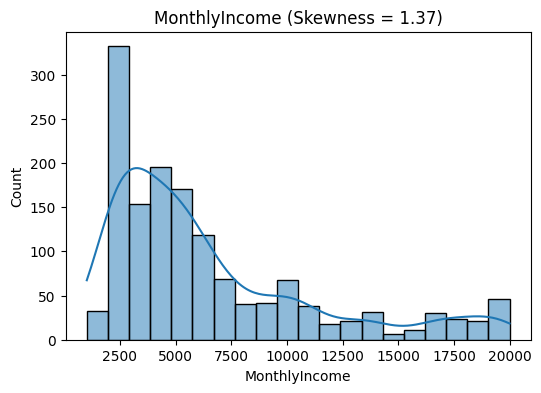

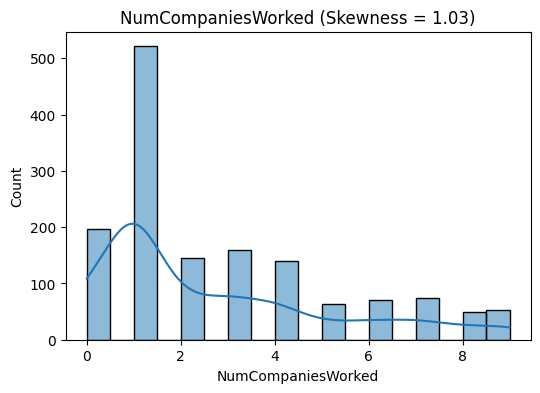

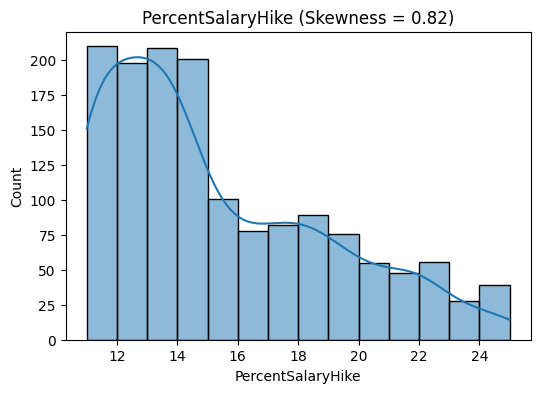

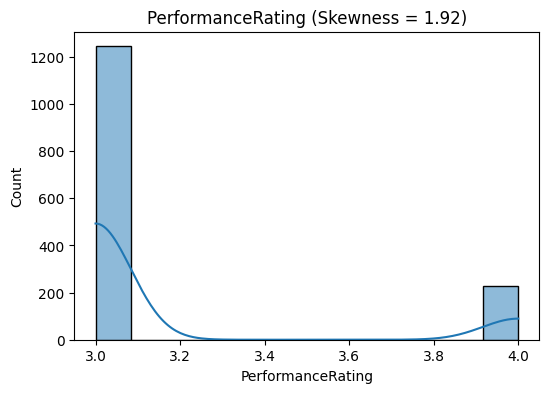

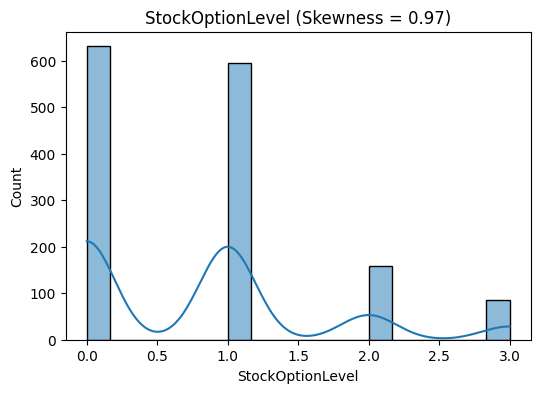

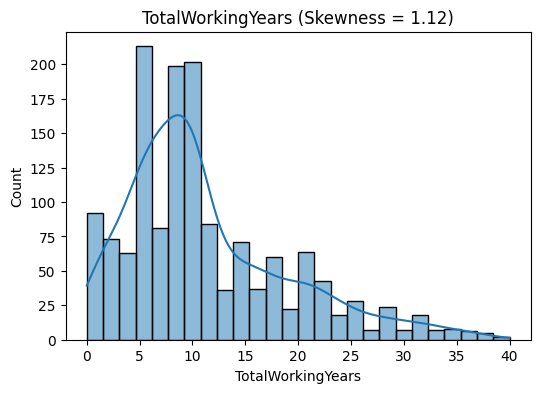

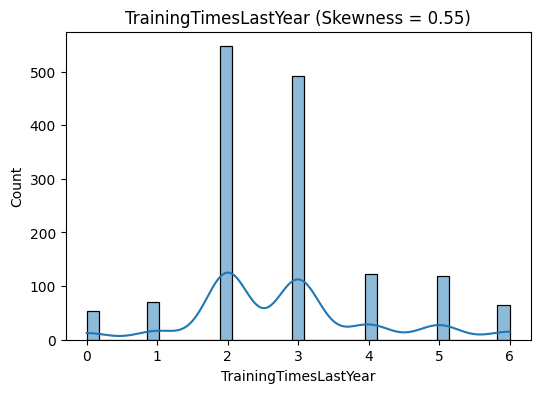

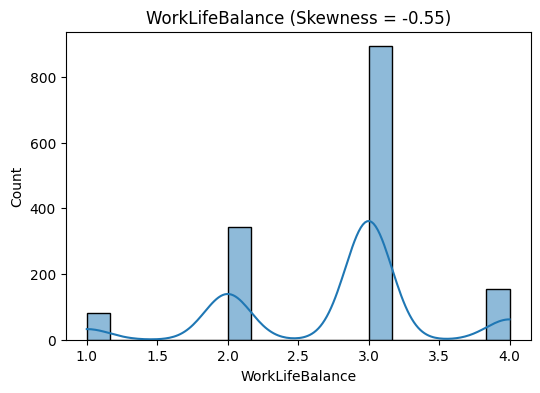

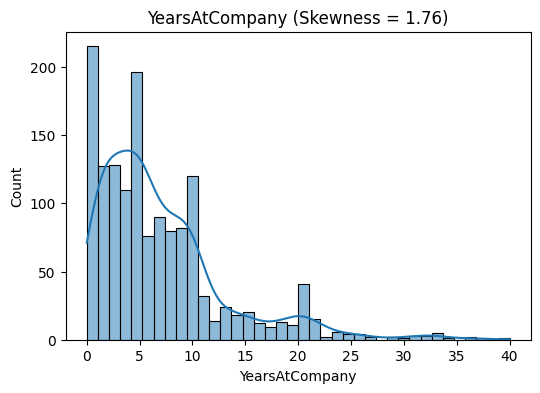

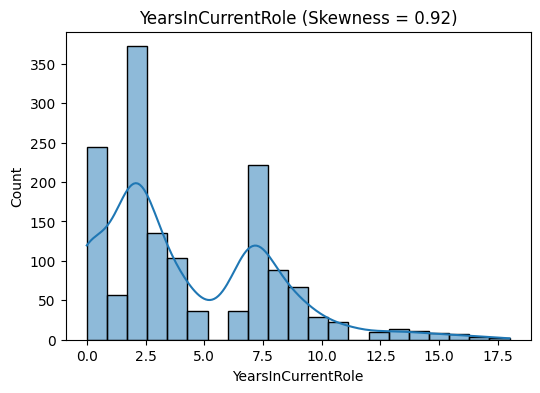

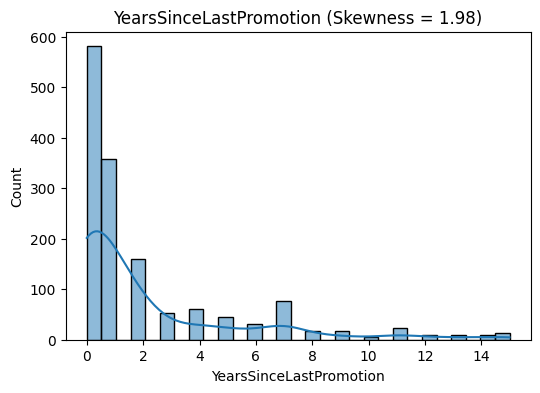

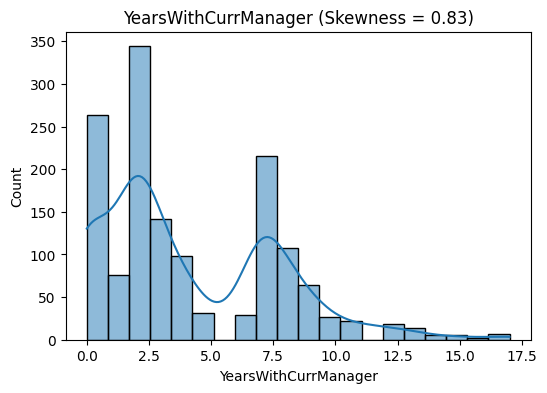

In [27]:
skewness = df.skew(numeric_only=True)

for col in skewness[abs(skewness) > 0.5].index:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} (Skewness = {skewness[col]:.2f})")
    plt.show()

In [28]:
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1}) # converting Attrition feature into numarical

##Observation
1.Dataset contains 1470 rows and 35 columns.

2.Outliers are present in these features TrainingTimesLastYear,PerformanceRating, MonthlyIncome, YearsSinceLastPromotion, YearsAtCompany, StockOptionLevel, TotalWorkingYears,NumCompaniesWorked, YearsInCurrentRole and YearsWithCurrManager

3.Target feature has an imbalanced data (83.87% and 16.13%)

4.'StandardHours ,'Over18' and  'EmployeeCount' has only 1 unique value it will not contribute for prediction so we can drop these 3 features

5.By observing the mean and 50% the feature 'DistanceFromHome' is right skwed and 'EmployeeNumber' is also little right skwed.
The 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion' and 'YearsWithCurrManager' its 75% amd max values comparionsion is very high, it may containe outliers.

6.DistanceFromHome,MonthlyIncome, NumCompaniesWorked, PerformanceRating, TotalWorkingYears, YearsAtCompany, YearsSinceLastPromotion and YearsWithCurrManager are highly right skewd



###Feature Engineering

In [29]:
df.drop(columns=['EmployeeNumber', 'Over18', 'StandardHours'], inplace=True)

In [30]:
df.shape

(1470, 32)

In [31]:
# Columns to check for outliers
columns = ["TrainingTimesLastYear","PerformanceRating", "MonthlyIncome", "YearsSinceLastPromotion", "YearsAtCompany", "StockOptionLevel", "TotalWorkingYears","NumCompaniesWorked", "YearsInCurrentRole", "YearsWithCurrManager"]

# Create a copy of the dataframe
df_clean = df.copy()

for col in columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Remove outliers
    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]

print("Original Shape:", df.shape)
print("Shape After Removing Outliers:", df_clean.shape)

Original Shape: (1470, 32)
Shape After Removing Outliers: (644, 32)


In [32]:
# handling the skwed features
from sklearn.preprocessing import PowerTransformer

# Columns to transform
cols = ['DistanceFromHome','MonthlyIncome','JobLevel','PerformanceRating', 'NumCompaniesWorked', 'PerformanceRating', 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

# Initialize transformer
pt = PowerTransformer(method="yeo-johnson")

# Apply transformation
df[cols] = pt.fit_transform(df[cols])

In [33]:
df.select_dtypes(include='object').columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [34]:
df['OverTime'].value_counts()

,count
OverTime,
No,1054
Yes,416


In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

#for col in cat_cols:
    #df[col] = le.fit_transform(df[col])

In [36]:
#converting object features into numarical features
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['OverTime'] = le.fit_transform(df['OverTime'])

In [37]:
#converting object features into numarical features
from sklearn.preprocessing import OneHotEncoder


cat_cols=['BusinessTravel', 'Department', 'EducationField', 'JobRole','MaritalStatus']

encoder = OneHotEncoder(drop='first', sparse_output=False)

for col in cat_cols:
  df[col] = encoder.fit_transform(df[[col]])


In [38]:
df.drop(columns=['EmployeeCount'], inplace=True)

In [39]:
df.shape

(1470, 31)

In [40]:
#feature selection

from sklearn.feature_selection import mutual_info_classif

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

mi = mutual_info_classif(X, y)

mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print(mi_scores)

OverTime                    0.035526
MonthlyIncome               0.033193
JobLevel                    0.028088
Age                         0.025427
YearsAtCompany              0.017084
NumCompaniesWorked          0.014207
TotalWorkingYears           0.014108
StockOptionLevel            0.013277
PercentSalaryHike           0.012038
JobSatisfaction             0.010676
YearsInCurrentRole          0.010277
YearsWithCurrManager        0.009266
Department                  0.008267
MaritalStatus               0.007246
EnvironmentSatisfaction     0.006684
YearsSinceLastPromotion     0.006608
DistanceFromHome            0.006423
RelationshipSatisfaction    0.005256
JobInvolvement              0.003714
DailyRate                   0.003024
TrainingTimesLastYear       0.003013
MonthlyRate                 0.001910
Education                   0.001544
EducationField              0.001241
Gender                      0.000094
BusinessTravel              0.000000
JobRole                     0.000000
H

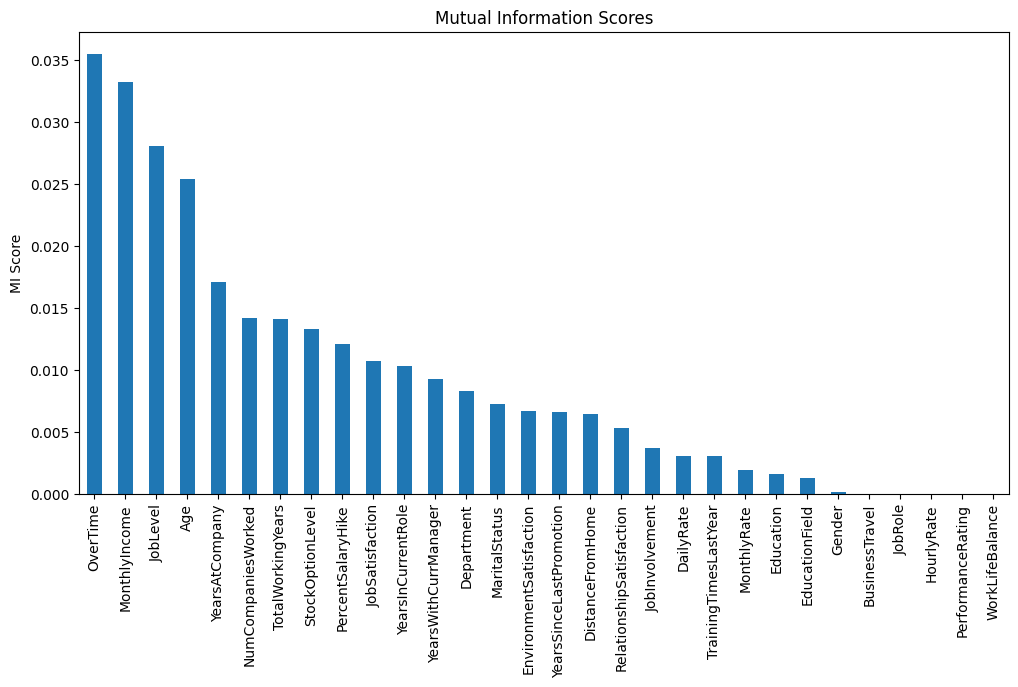

In [41]:
import matplotlib.pyplot as plt

mi_scores.plot(kind="bar", figsize=(12,6))
plt.title("Mutual Information Scores")
plt.ylabel("MI Score")
plt.show()

In [42]:
selected_features = mi_scores[mi_scores > 0].index

X_selected = X[selected_features]

print(selected_features)

Index(['OverTime', 'MonthlyIncome', 'JobLevel', 'Age', 'YearsAtCompany',
       'NumCompaniesWorked', 'TotalWorkingYears', 'StockOptionLevel',
       'PercentSalaryHike', 'JobSatisfaction', 'YearsInCurrentRole',
       'YearsWithCurrManager', 'Department', 'MaritalStatus',
       'EnvironmentSatisfaction', 'YearsSinceLastPromotion',
       'DistanceFromHome', 'RelationshipSatisfaction', 'JobInvolvement',
       'DailyRate', 'TrainingTimesLastYear', 'MonthlyRate', 'Education',
       'EducationField', 'Gender'],
      dtype='object')


In [43]:
print(X.shape)
print(X_selected.shape)

(1470, 30)
(1470, 25)


#Train Test Split

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=50,
    stratify=y
)

#Train a Model

In [45]:
# 2. Globally activate automated metric tracking
mlflow.autolog()

2026/08/07 18:59:16 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/08/07 18:59:19 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/08/07 18:59:19 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2026/08/07 18:59:19 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.


In [46]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
with mlflow.start_run(run_name="LogisticRegression"):
  model = LogisticRegression(max_iter=10000)
  model.fit(X_train, y_train)

2026/08/07 18:59:20 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/08/07 19:00:18 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils

In [47]:
from sklearn.metrics import accuracy_score, classification_report

#LogisticRegression
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

2026/08/07 19:00:27 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Accuracy: 0.8741496598639455
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       247
           1       0.73      0.34      0.46        47

    accuracy                           0.87       294
   macro avg       0.81      0.66      0.70       294
weighted avg       0.86      0.87      0.85       294



In [48]:
# Evalution for LogisticRegression
#ROC
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

#AUC
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

2026/08/07 19:00:27 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


AUC Score: 0.7940391075889396


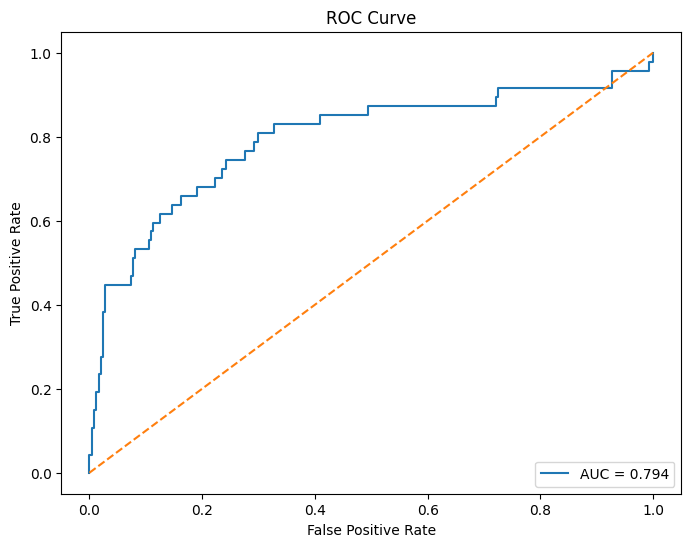

In [49]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

# Diagonal line (random classifier)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

In [50]:
# RandomeForest

from sklearn.ensemble import RandomForestClassifier
with mlflow.start_run(run_name="Random_Forest_Mdl"):
  model2 = RandomForestClassifier(n_estimators=100,max_depth=6,random_state=50)
  model2.fit(X_train, y_train)

2026/08/07 19:00:27 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/08/07 19:00:27 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils

In [51]:
# RandomForest
y_pred2 = model2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

2026/08/07 19:00:35 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Accuracy: 0.8605442176870748
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       247
           1       0.88      0.15      0.25        47

    accuracy                           0.86       294
   macro avg       0.87      0.57      0.59       294
weighted avg       0.86      0.86      0.82       294



In [52]:
accuracy = accuracy_score(y_test, y_pred2)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8605442176870748


In [53]:
# Evalution for RandomForest
#ROC
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = model2.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

#AUC
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

2026/08/07 19:00:35 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


AUC Score: 0.7966233095012489


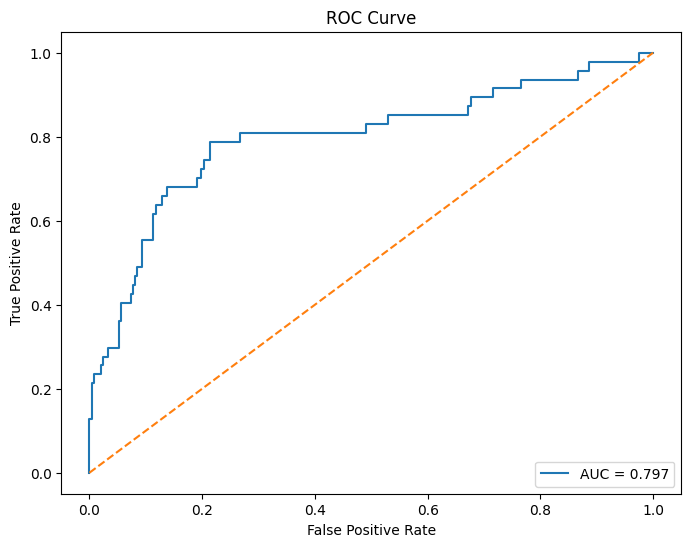

In [54]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

# Diagonal line (random classifier)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")


plt.legend(loc="lower right")

plt.show()

In [55]:
from xgboost import XGBClassifier
with mlflow.start_run(run_name="XGBoost_Advanced"):
  xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=50,
    eval_metric="auc"
  )

2026/08/07 19:00:35 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.


In [56]:
xgb_model.fit(X_train, y_train)

2026/08/07 19:00:35 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '5a476753ab3041b6a074e3e7da4fcf4b', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
2026/08/07 19:00:36 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https:/

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [57]:
# XGBoost
y_pred3 = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred3))
print(classification_report(y_test, y_pred3))

2026/08/07 19:00:40 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Accuracy: 0.8639455782312925
              precision    recall  f1-score   support

           0       0.88      0.98      0.92       247
           1       0.68      0.28      0.39        47

    accuracy                           0.86       294
   macro avg       0.78      0.63      0.66       294
weighted avg       0.85      0.86      0.84       294



In [58]:
accuracy = accuracy_score(y_test, y_pred3)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8639455782312925


In [59]:
# Evalution for XGBoost
#ROC
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = xgb_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

#AUC
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

2026/08/07 19:00:40 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


AUC Score: 0.7648376259798433


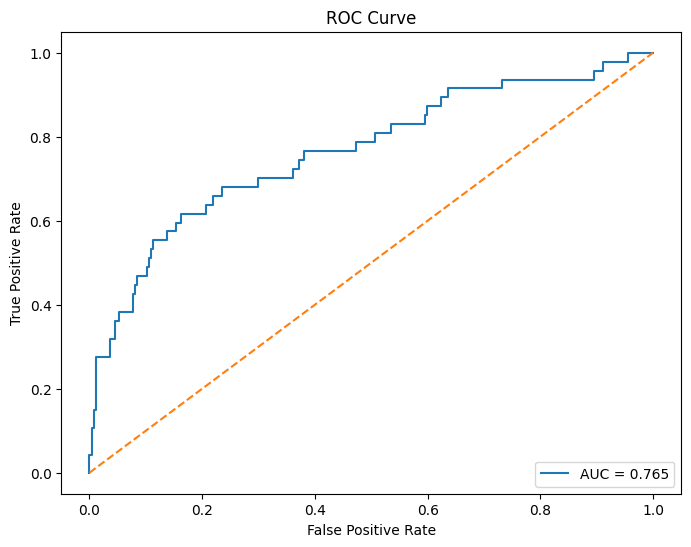

In [60]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

# Diagonal line (random classifier)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

# MLflow

In [61]:
#!pkill -f mlflow
#!pkill -f ngrok


In [62]:
# # 2. Start an MLflow run
# with mlflow.start_run():
#     # Define hyperparameters
#     n_estimators = 100
#     max_depth = 5
#     random_state = 50

# # Log hyperparameters
# mlflow.log_param("n_estimators", n_estimators)
# mlflow.log_param("max_depth", max_depth)
# #mlflow.log_param("learning_rate", learning_rate)
# #mlflow.log_param("eval_metric", eval_metric)
# mlflow.log_param("random_state", random_state)


# # Log metric
# mlflow.log_metric("accuracy", accuracy)

# # Log the trained model artifact
# mlflow.sklearn.log_model(model2, "RandomForest")

# print(f"Run completed! accuracy: {accuracy}")

In [82]:
import mlflow
from mlflow.tracking import MlflowClient

# 1. Establish the tracking destination database
#mlflow.set_tracking_uri("sqlite:///mlflow.db")
client = MlflowClient()

# 2. Extract run configurations from your experiment
experiment_name = "employee_attrition"
experiment = client.get_experiment_by_name(experiment_name)
experiment_id = experiment.experiment_id

# 3. Pull all completed tracking runs
runs_df = mlflow.search_runs(experiment_ids=[experiment_id])

# Format: df = df[df['column_name'] != value]
# The ~ operator means "NOT", filtering out the matching run IDs cleanly
runs_df = runs_df[~runs_df['run_id'].isin(['66d134f539cd460798183cb81838f4ce', '0e8b4d3b21884d52a232b14f569c5b6b','b59326483e96405ea0378366557dc72c'])]

# 4. Target the correct metric name from your dataset
possible_metrics = ["metrics.test_accuracy", "metrics.accuracy", "metrics.accuracy_score_X_test"]
accuracy_col = None

for metric in possible_metrics:
    if metric in runs_df.columns:
        accuracy_col = metric
        break

if not accuracy_col:
    raise ValueError("No matching test accuracy metrics found in your database runs.")

# 5. Sort descending and extract the winning metrics row smoothly
runs_df = runs_df.sort_values(by=accuracy_col, ascending=False)
best_run = runs_df.iloc[0]
best_run_id = best_run["run_id"]
best_run_name = best_run["tags.mlflow.runName"]
best_score = best_run[accuracy_col]

# ========================================================
# 6. DYNAMIC SCANNER (FIXES THE MLFLOWEXCEPTION ERROR)
# ========================================================
# This scans the files inside run 66d134f53... to find the real model folder
artifacts = client.list_artifacts(best_run_id)
real_artifact_path = None

for art in artifacts:
    if art.is_dir:
        # Check inside this directory to verify if it contains MLmodel metadata files
        sub_files = [f.path for f in client.list_artifacts(best_run_id, path=art.path)]
        if any("MLmodel" in f for f in sub_files):
            real_artifact_path = art.path
            break

# Emergency fallback if the metadata scanner is restricted
if not real_artifact_path:
    directories = [art.path for art in artifacts if art.is_dir]
    real_artifact_path = directories[0] if directories else "model"

print("---" * 15)
print(f"🥇 WINNING MODEL RUN: {best_run_name}")
print(f"📊 Best Accuracy Metric: {best_score:.4f}")
print(f"🆔 Run ID Key: {best_run_id}")
print(f"📁 Verified Artifact Path Found: '{real_artifact_path}'")
print("---" * 15)

# 7. Construct URI and register the model cleanly into the Model Registry
model_uri = f"runs:/{best_run_id}/{real_artifact_path}"
registered_model_name = "Best_Attrition_Prediction_Model"

model_details = mlflow.register_model(
    model_uri=model_uri,
    name=registered_model_name
)

print(f"🎉 Success! Registered as: '{model_details.name}'")
print(f"📦 Active Version Number: Version {model_details.version}")


Registered model 'Best_Attrition_Prediction_Model' already exists. Creating a new version of this model...
2026/08/07 19:58:33 WARNING mlflow.tracking._model_registry.fluent: Run with id 5a476753ab3041b6a074e3e7da4fcf4b has no artifacts at artifact path 'model', registering model based on models:/m-7a55f01a2e5b4951a99c187aad950a18 instead


---------------------------------------------
🥇 WINNING MODEL RUN: brawny-fly-377
📊 Best Accuracy Metric: nan
🆔 Run ID Key: 5a476753ab3041b6a074e3e7da4fcf4b
📁 Verified Artifact Path Found: 'model'
---------------------------------------------
🎉 Success! Registered as: 'Best_Attrition_Prediction_Model'
📦 Active Version Number: Version 3


Created version '3' of model 'Best_Attrition_Prediction_Model'.


In [79]:
# Format: df[df['column_name'] == value]
matched_rows = runs_df[runs_df['run_id'] == '0e8b4d3b21884d52a232b14f569c5b6b']
matched_rows

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.accuracy_score_X_test,metrics.accuracy_score-2_X_test,metrics.training_log_loss,metrics.training_precision_score,...,params.solver,params.l1_ratio,params.dual,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.autologging,tags.mlflow.source.type,tags.estimator_name,tags.estimator_class
16,0e8b4d3b21884d52a232b14f569c5b6b,1,FINISHED,/content/mlruns/1/0e8b4d3b21884d52a232b14f569c...,2026-08-07 16:10:20.377000+00:00,2026-08-07 16:18:00.663000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,orderly-crow-63,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,None,None


In [77]:
# Format: df = df[df['column_name'] != value]
runs_df = runs_df[runs_df['run_id'] != '66d134f539cd460798183cb81838f4ce']
runs_df


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.accuracy_score_X_test,metrics.accuracy_score-2_X_test,metrics.training_log_loss,metrics.training_precision_score,...,params.solver,params.l1_ratio,params.dual,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.autologging,tags.mlflow.source.type,tags.estimator_name,tags.estimator_class
16,0e8b4d3b21884d52a232b14f569c5b6b,1,FINISHED,/content/mlruns/1/0e8b4d3b21884d52a232b14f569c...,2026-08-07 16:10:20.377000+00:00,2026-08-07 16:18:00.663000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,orderly-crow-63,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,None,None
14,b59326483e96405ea0378366557dc72c,1,RUNNING,/content/mlruns/1/b59326483e96405ea0378366557d...,2026-08-07 16:18:05.601000+00:00,NaT,NaN,NaN,NaN,NaN,...,None,None,None,handsome-shrike-986,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,None,None
0,5a476753ab3041b6a074e3e7da4fcf4b,1,FINISHED,/content/mlruns/1/5a476753ab3041b6a074e3e7da4f...,2026-08-07 19:00:35.661000+00:00,2026-08-07 19:00:40.618000+00:00,0.863946,0.863946,NaN,NaN,...,None,None,None,brawny-fly-377,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,xgboost,NOTEBOOK,None,None
1,0d22fab2a2bf4a9f9242d30ef0f02d96,1,FINISHED,/content/mlruns/1/0d22fab2a2bf4a9f9242d30ef0f0...,2026-08-07 19:00:35.617000+00:00,2026-08-07 19:00:35.638000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,XGBoost_Advanced,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,None,None
2,940654ef798448fb861ebbf5b10a1efe,1,FINISHED,/content/mlruns/1/940654ef798448fb861ebbf5b10a...,2026-08-07 19:00:27.591000+00:00,2026-08-07 19:00:34.944000+00:00,0.860544,0.860544,0.247694,0.906337,...,None,None,None,Random_Forest_Mdl,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,RandomForestClassifier,sklearn.ensemble._forest.RandomForestClassifier
3,2d4da99507474280b834a9a18b9c08d7,1,FINISHED,/content/mlruns/1/2d4da99507474280b834a9a18b9c...,2026-08-07 18:59:20.121000+00:00,2026-08-07 19:00:27.100000+00:00,0.874150,NaN,0.309789,0.886696,...,lbfgs,None,False,LogisticRegression,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,LogisticRegression,sklearn.linear_model._logistic.LogisticRegression
4,a7759818127441ed8ffee5b9b17b0a72,1,FINISHED,/content/mlruns/1/a7759818127441ed8ffee5b9b17b...,2026-08-07 18:48:27.585000+00:00,2026-08-07 18:48:33.741000+00:00,0.863946,0.863946,NaN,NaN,...,None,None,None,indecisive-flea-18,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,xgboost,NOTEBOOK,None,None
5,42c509c1d723409f926692cbc980d876,1,FINISHED,/content/mlruns/1/42c509c1d723409f926692cbc980...,2026-08-07 18:48:27.540000+00:00,2026-08-07 18:48:27.561000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,XGBoost_Advanced,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,None,None
6,e44bdaf4832541fdbcd999837016b17c,1,FINISHED,/content/mlruns/1/e44bdaf4832541fdbcd999837016...,2026-08-07 18:48:21.246000+00:00,2026-08-07 18:48:27.080000+00:00,0.860544,0.860544,0.253988,0.904549,...,None,None,None,Random_Forest_Mdl,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,RandomForestClassifier,sklearn.ensemble._forest.RandomForestClassifier
7,68b75d21b08d48e98baa03a30e6e17b5,1,FINISHED,/content/mlruns/1/68b75d21b08d48e98baa03a30e6e...,2026-08-07 18:46:43.927000+00:00,2026-08-07 18:48:20.900000+00:00,0.870748,NaN,0.319042,0.880709,...,lbfgs,None,False,LogisticRegression,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,LogisticRegression,sklearn.linear_model._logistic.LogisticRegression


In [70]:
display(runs_df)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.accuracy_score_X_test,metrics.accuracy_score-2_X_test,metrics.training_log_loss,metrics.training_precision_score,...,params.solver,params.l1_ratio,params.dual,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.autologging,tags.mlflow.source.type,tags.estimator_name,tags.estimator_class
12,66d134f539cd460798183cb81838f4ce,1,RUNNING,/content/mlruns/1/66d134f539cd460798183cb81838...,2026-08-07 17:34:16.532000+00:00,NaT,NaN,NaN,NaN,NaN,...,None,None,None,big-mule-729,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,None,None
16,0e8b4d3b21884d52a232b14f569c5b6b,1,FINISHED,/content/mlruns/1/0e8b4d3b21884d52a232b14f569c...,2026-08-07 16:10:20.377000+00:00,2026-08-07 16:18:00.663000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,orderly-crow-63,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,None,None
14,b59326483e96405ea0378366557dc72c,1,RUNNING,/content/mlruns/1/b59326483e96405ea0378366557d...,2026-08-07 16:18:05.601000+00:00,NaT,NaN,NaN,NaN,NaN,...,None,None,None,handsome-shrike-986,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,None,None
0,5a476753ab3041b6a074e3e7da4fcf4b,1,FINISHED,/content/mlruns/1/5a476753ab3041b6a074e3e7da4f...,2026-08-07 19:00:35.661000+00:00,2026-08-07 19:00:40.618000+00:00,0.863946,0.863946,NaN,NaN,...,None,None,None,brawny-fly-377,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,xgboost,NOTEBOOK,None,None
1,0d22fab2a2bf4a9f9242d30ef0f02d96,1,FINISHED,/content/mlruns/1/0d22fab2a2bf4a9f9242d30ef0f0...,2026-08-07 19:00:35.617000+00:00,2026-08-07 19:00:35.638000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,XGBoost_Advanced,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,None,None
2,940654ef798448fb861ebbf5b10a1efe,1,FINISHED,/content/mlruns/1/940654ef798448fb861ebbf5b10a...,2026-08-07 19:00:27.591000+00:00,2026-08-07 19:00:34.944000+00:00,0.860544,0.860544,0.247694,0.906337,...,None,None,None,Random_Forest_Mdl,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,RandomForestClassifier,sklearn.ensemble._forest.RandomForestClassifier
3,2d4da99507474280b834a9a18b9c08d7,1,FINISHED,/content/mlruns/1/2d4da99507474280b834a9a18b9c...,2026-08-07 18:59:20.121000+00:00,2026-08-07 19:00:27.100000+00:00,0.874150,NaN,0.309789,0.886696,...,lbfgs,None,False,LogisticRegression,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,LogisticRegression,sklearn.linear_model._logistic.LogisticRegression
4,a7759818127441ed8ffee5b9b17b0a72,1,FINISHED,/content/mlruns/1/a7759818127441ed8ffee5b9b17b...,2026-08-07 18:48:27.585000+00:00,2026-08-07 18:48:33.741000+00:00,0.863946,0.863946,NaN,NaN,...,None,None,None,indecisive-flea-18,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,xgboost,NOTEBOOK,None,None
5,42c509c1d723409f926692cbc980d876,1,FINISHED,/content/mlruns/1/42c509c1d723409f926692cbc980...,2026-08-07 18:48:27.540000+00:00,2026-08-07 18:48:27.561000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,XGBoost_Advanced,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,None,None
6,e44bdaf4832541fdbcd999837016b17c,1,FINISHED,/content/mlruns/1/e44bdaf4832541fdbcd999837016...,2026-08-07 18:48:21.246000+00:00,2026-08-07 18:48:27.080000+00:00,0.860544,0.860544,0.253988,0.904549,...,None,None,None,Random_Forest_Mdl,root,fileId=1B0Elrh4VxXeXQezuOeDUHAEvy4188l5E,None,NOTEBOOK,RandomForestClassifier,sklearn.ensemble._forest.RandomForestClassifier


In [ ]:
mlflow.end_run()